# EDA — Predicción Musical TFM

Análisis exploratorio de la matriz de features `data/processed/artist_features.csv`.

**125 artistas · 30 features · 3 clases (bajo / medio / alto)**

Fuentes: Spotify (discografía + top tracks) · Last.fm · YouTube · setlist.fm

## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Apuntar al root del proyecto independientemente de dónde se lance jupyter
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = {'bajo': '#4C72B0', 'medio': '#DD8452', 'alto': '#55A868'}
ORDEN   = ['bajo', 'medio', 'alto']

print(f'ROOT: {ROOT}')

ROOT: c:\Users\vicho\PROYECTOS\prediccion_musical_TFM


## 1. Carga de datos

In [2]:
df = pd.read_csv(ROOT / 'data' / 'processed' / 'artist_features.csv')

# Columnas de features (excluir metadata y target)
META     = ['nombre_buscado', 'nivel', 'tier_sala', 'target']
FEATURES = [c for c in df.columns if c not in META]

# Grupos de features por fuente
FEAT_SP  = [c for c in FEATURES if c.startswith('sp_')]
FEAT_LFM = [c for c in FEATURES if c.startswith('lfm_')]
FEAT_YT  = [c for c in FEATURES if c.startswith('yt_')]
FEAT_SL  = [c for c in FEATURES if c.startswith('sl_')]

print(f'Shape: {df.shape}')
print(f'Features totales: {len(FEATURES)}')
print(f'  Spotify: {len(FEAT_SP)} | Last.fm: {len(FEAT_LFM)} | YouTube: {len(FEAT_YT)} | setlist.fm: {len(FEAT_SL)}')
df.head(3)

Shape: (125, 34)
Features totales: 30
  Spotify: 11 | Last.fm: 6 | YouTube: 8 | setlist.fm: 5


,nombre_buscado,nivel,tier_sala,target,sp_num_albums,sp_num_singles,sp_num_eps,sp_num_total_releases,sp_anos_activo,sp_releases_por_ano,...,yt_vistas_log,yt_num_videos,yt_vistas_por_video,yt_vistas_por_suscriptor,yt_edad_canal_anos,sl_avg_canciones,sl_pct_encore,sl_num_paises,sl_num_conciertos,sl_pct_espana
0,Tarchi,bajo,1,1,3,7,0,10,5.0,2.00,...,14.711906,55.0,44559.145455,276.921243,5.837098,NaN,NaN,NaN,NaN,NaN
1,Guxo,medio,2,2,8,15,0,23,4.0,5.75,...,14.912254,45.0,66542.177778,553.493161,7.173169,NaN,NaN,1.0,2.0,1.0
2,Bon Calso,medio,2,2,4,6,0,10,8.0,1.25,...,16.053500,79.0,118664.126582,582.264969,7.197810,1.363636,0.0,1.0,22.0,1.0


## 2. Valores nulos

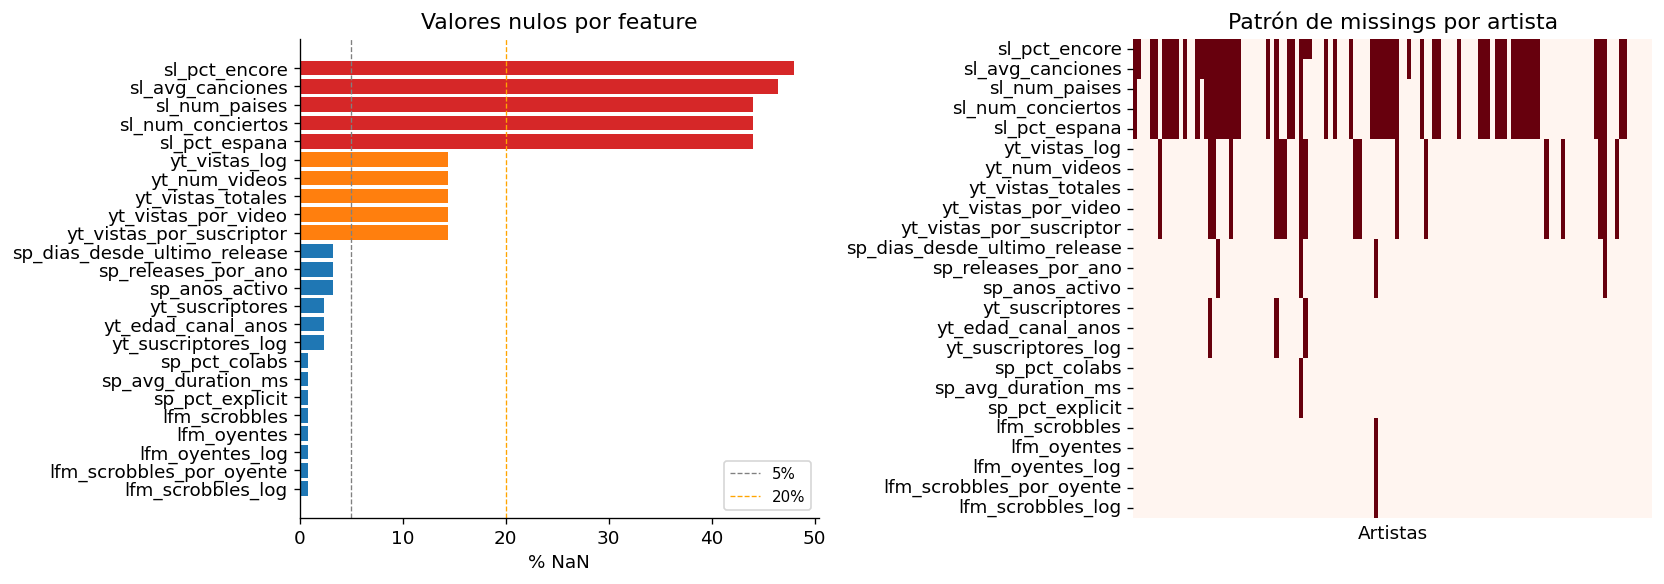


Features con >10% NaN:
sl_pct_encore               48.0
sl_avg_canciones            46.4
sl_num_paises               44.0
sl_num_conciertos           44.0
sl_pct_espana               44.0
yt_vistas_log               14.4
yt_num_videos               14.4
yt_vistas_totales           14.4
yt_vistas_por_video         14.4
yt_vistas_por_suscriptor    14.4


In [3]:
nan_pct = (df[FEATURES].isna().sum() / len(df) * 100).sort_values(ascending=False)
nan_pct = nan_pct[nan_pct > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot % NaN por feature
colors = ['#d62728' if v > 30 else '#ff7f0e' if v > 10 else '#1f77b4' for v in nan_pct]
axes[0].barh(nan_pct.index[::-1], nan_pct.values[::-1], color=colors[::-1])
axes[0].axvline(5, color='grey', linestyle='--', linewidth=0.8, label='5%')
axes[0].axvline(20, color='orange', linestyle='--', linewidth=0.8, label='20%')
axes[0].set_xlabel('% NaN')
axes[0].set_title('Valores nulos por feature')
axes[0].legend(fontsize=9)

# Heatmap de missings por artista (solo features con NaN)
feat_con_nan = nan_pct.index.tolist()
miss_matrix  = df[feat_con_nan].isna().astype(int)
miss_matrix.index = df['nombre_buscado']
sns.heatmap(miss_matrix.T, cmap='Reds', cbar=False, ax=axes[1],
            xticklabels=False, yticklabels=True)
axes[1].set_title('Patrón de missings por artista')
axes[1].set_xlabel('Artistas')

plt.tight_layout()
plt.show()

print('\nFeatures con >10% NaN:')
print(nan_pct[nan_pct > 10].to_string())

## 3. Distribución del target

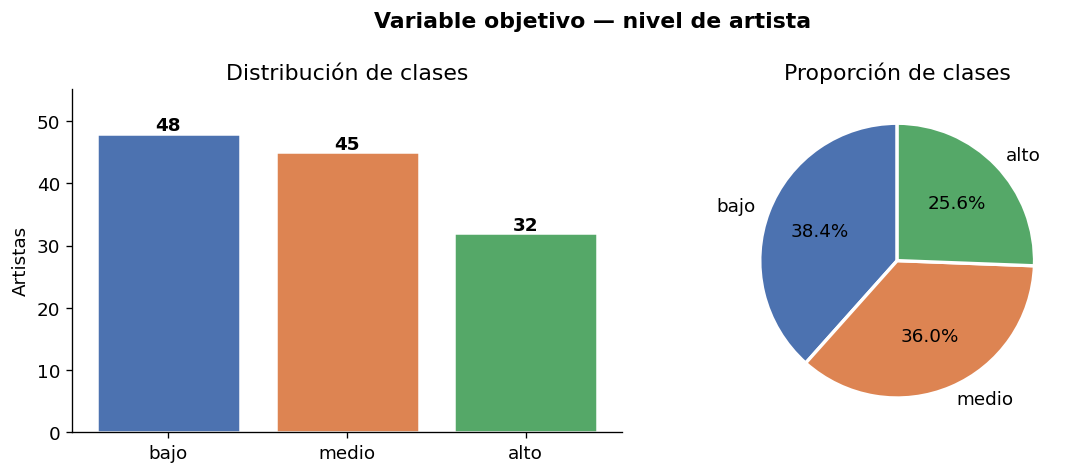

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['nivel'].value_counts().reindex(ORDEN)
axes[0].bar(counts.index, counts.values,
            color=[PALETTE[n] for n in counts.index], edgecolor='white', linewidth=1.5)
for i, (nivel, v) in enumerate(counts.items()):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Artistas')
axes[0].set_ylim(0, counts.max() * 1.15)

axes[1].pie(counts.values, labels=counts.index,
            colors=[PALETTE[n] for n in counts.index],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de clases')

plt.suptitle('Variable objetivo — nivel de artista', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Distribución de features

C:\Users\vicho\AppData\Local\Temp\ipykernel_19272\1620106414.py:16: UserWarning: Glyph 128192 (\N{DVD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\vicho\PROYECTOS\prediccion_musical_TFM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128192 (\N{DVD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


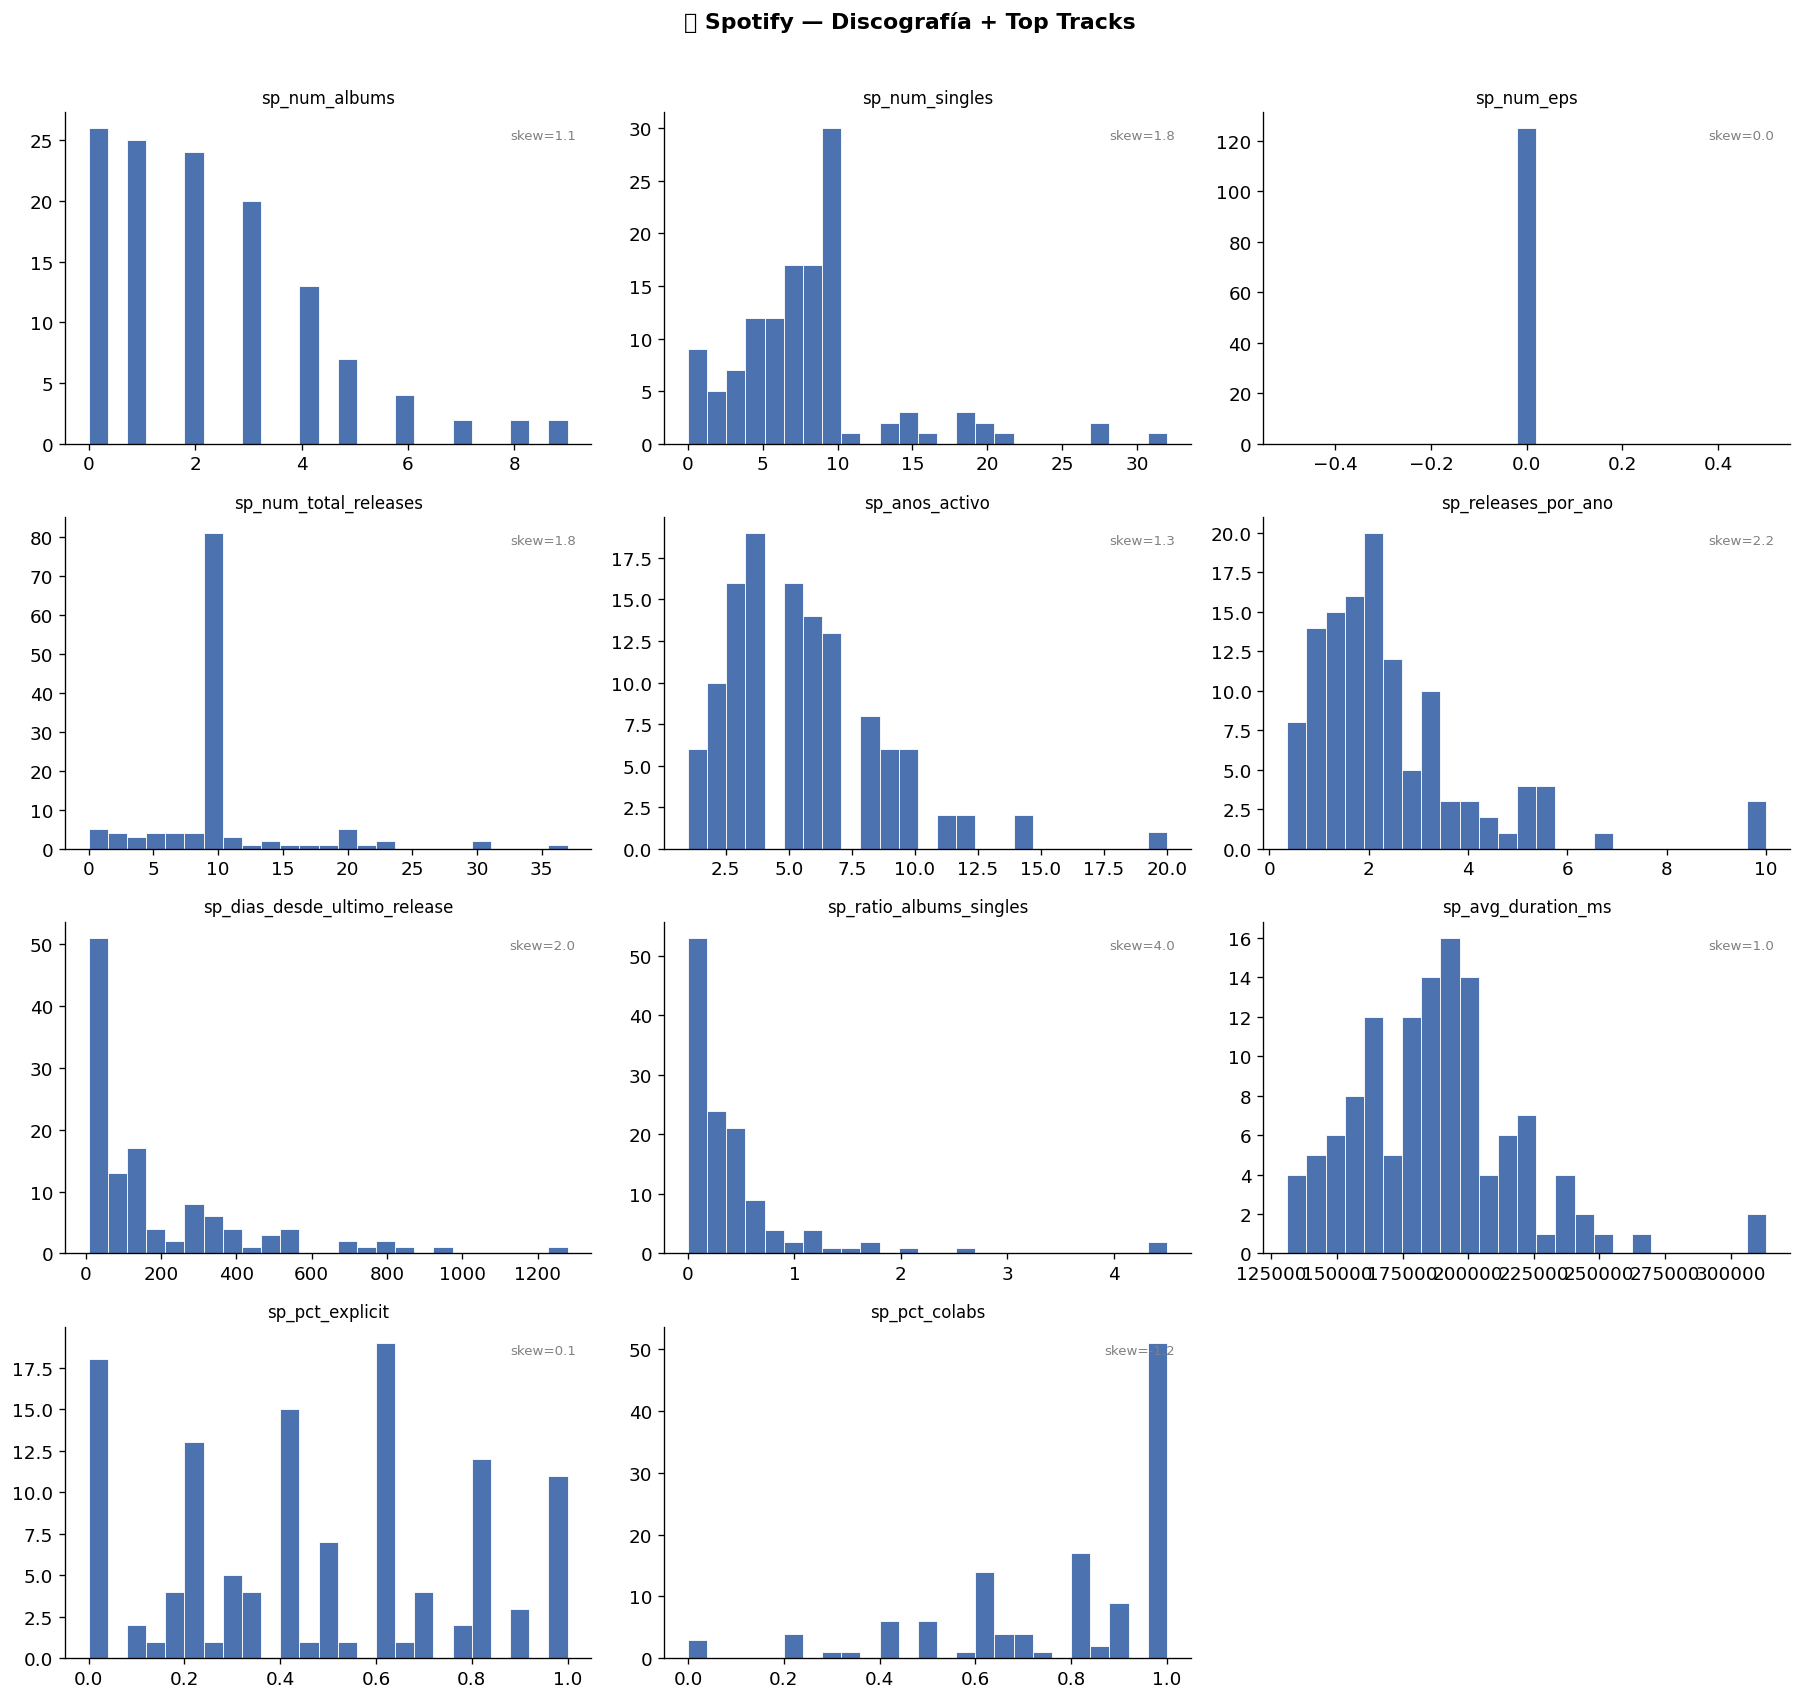

C:\Users\vicho\AppData\Local\Temp\ipykernel_19272\1620106414.py:16: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\vicho\PROYECTOS\prediccion_musical_TFM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


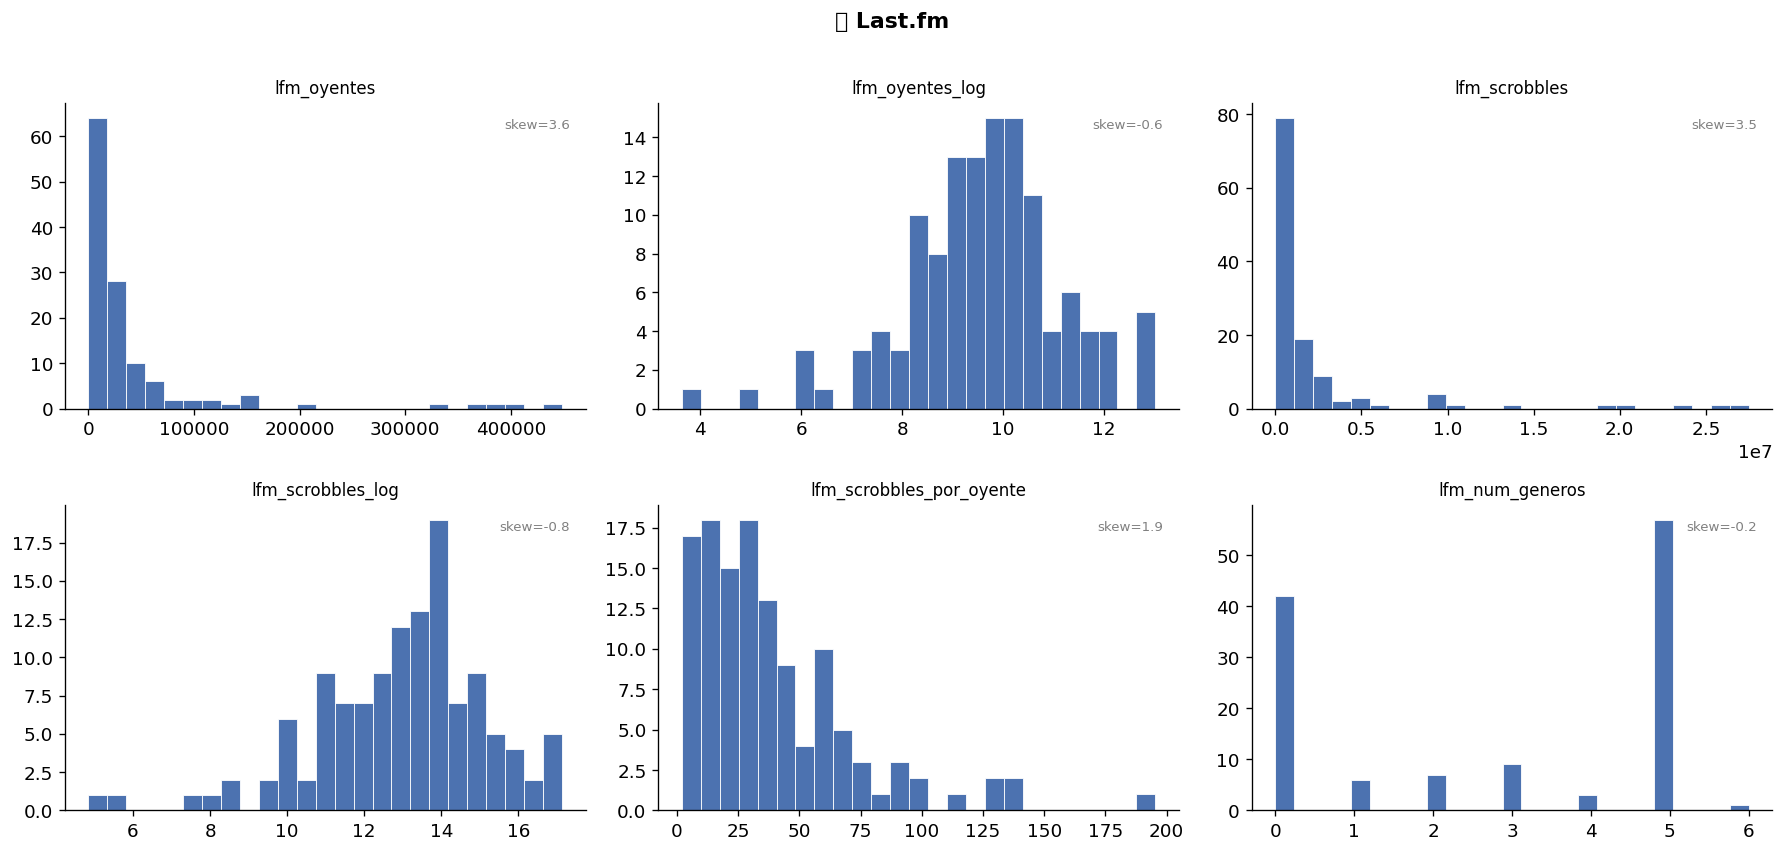

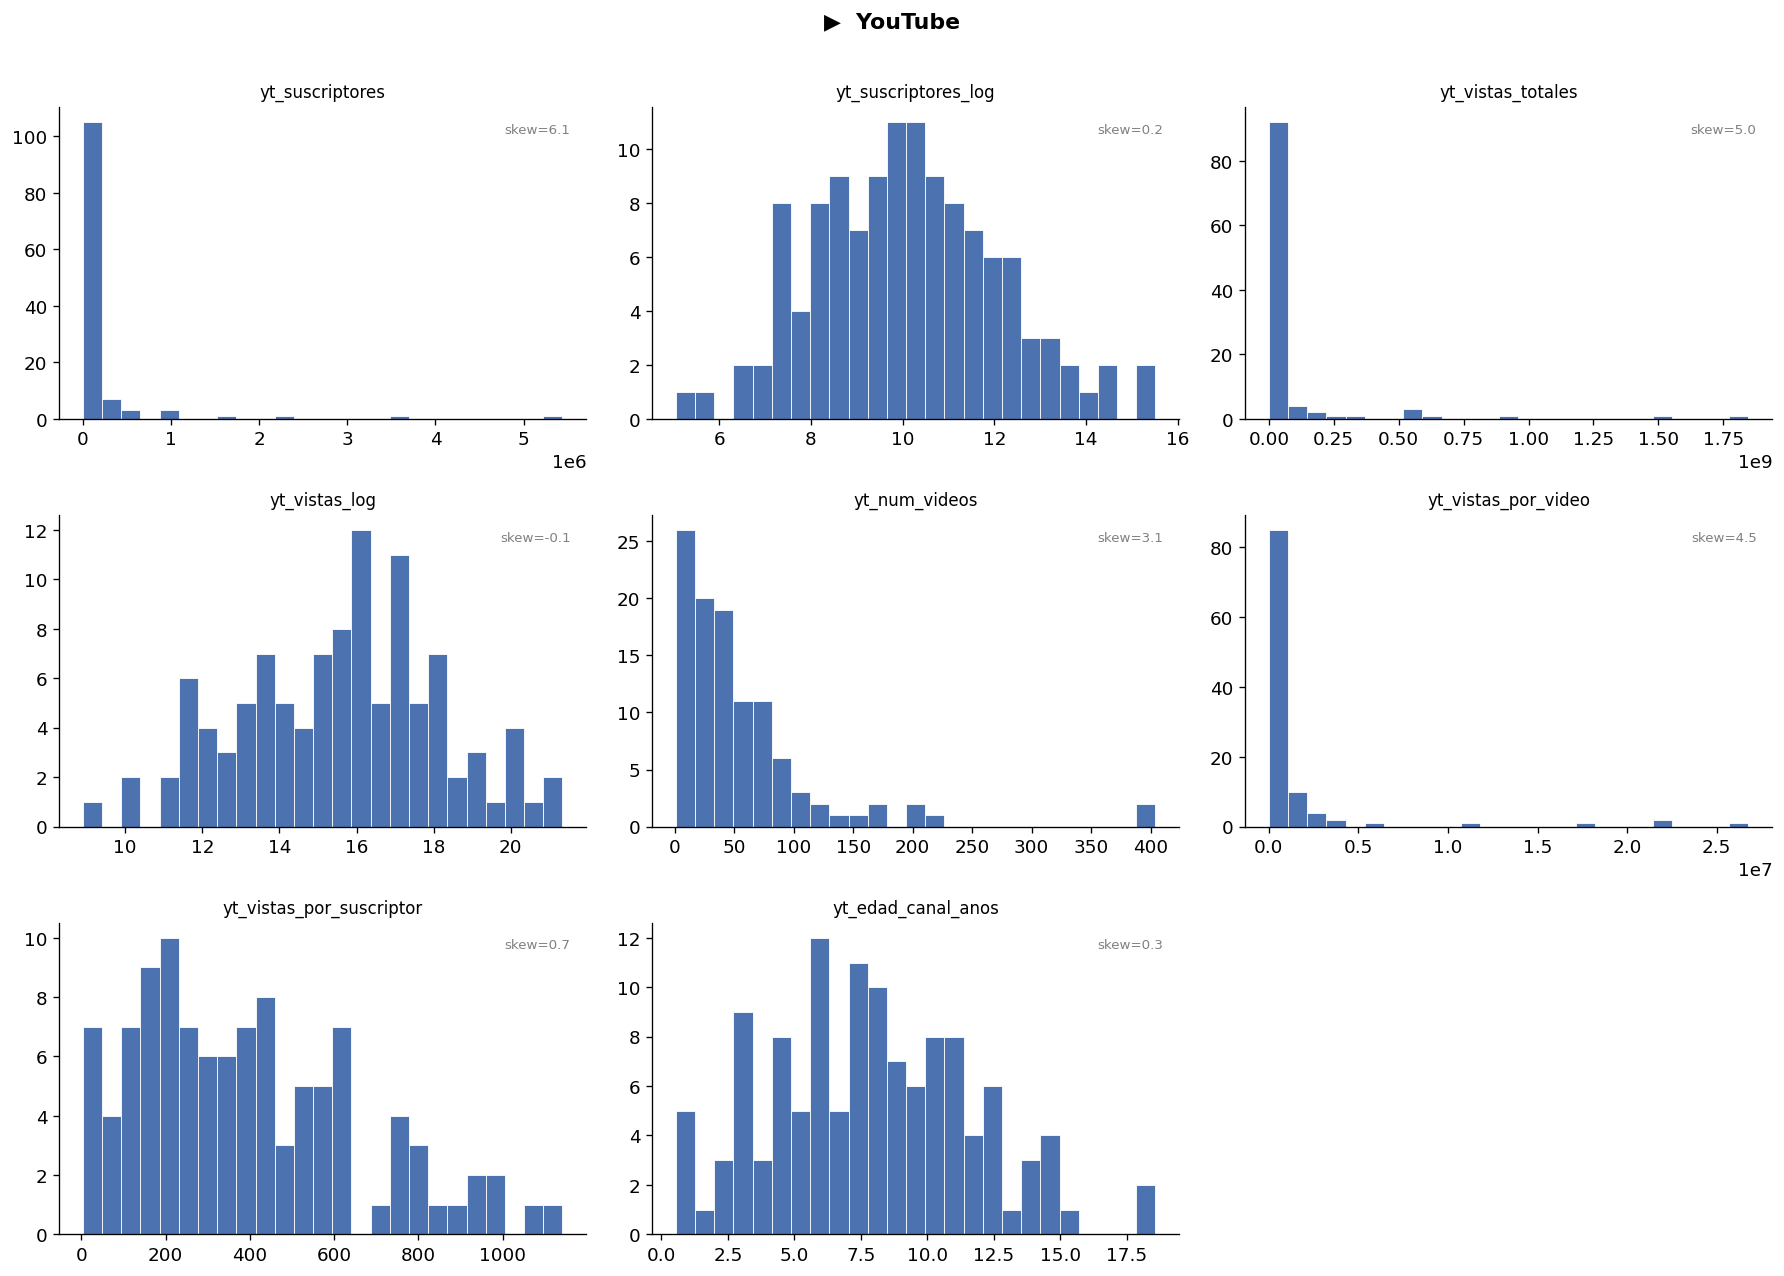

C:\Users\vicho\AppData\Local\Temp\ipykernel_19272\1620106414.py:16: UserWarning: Glyph 127908 (\N{MICROPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\vicho\PROYECTOS\prediccion_musical_TFM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127908 (\N{MICROPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


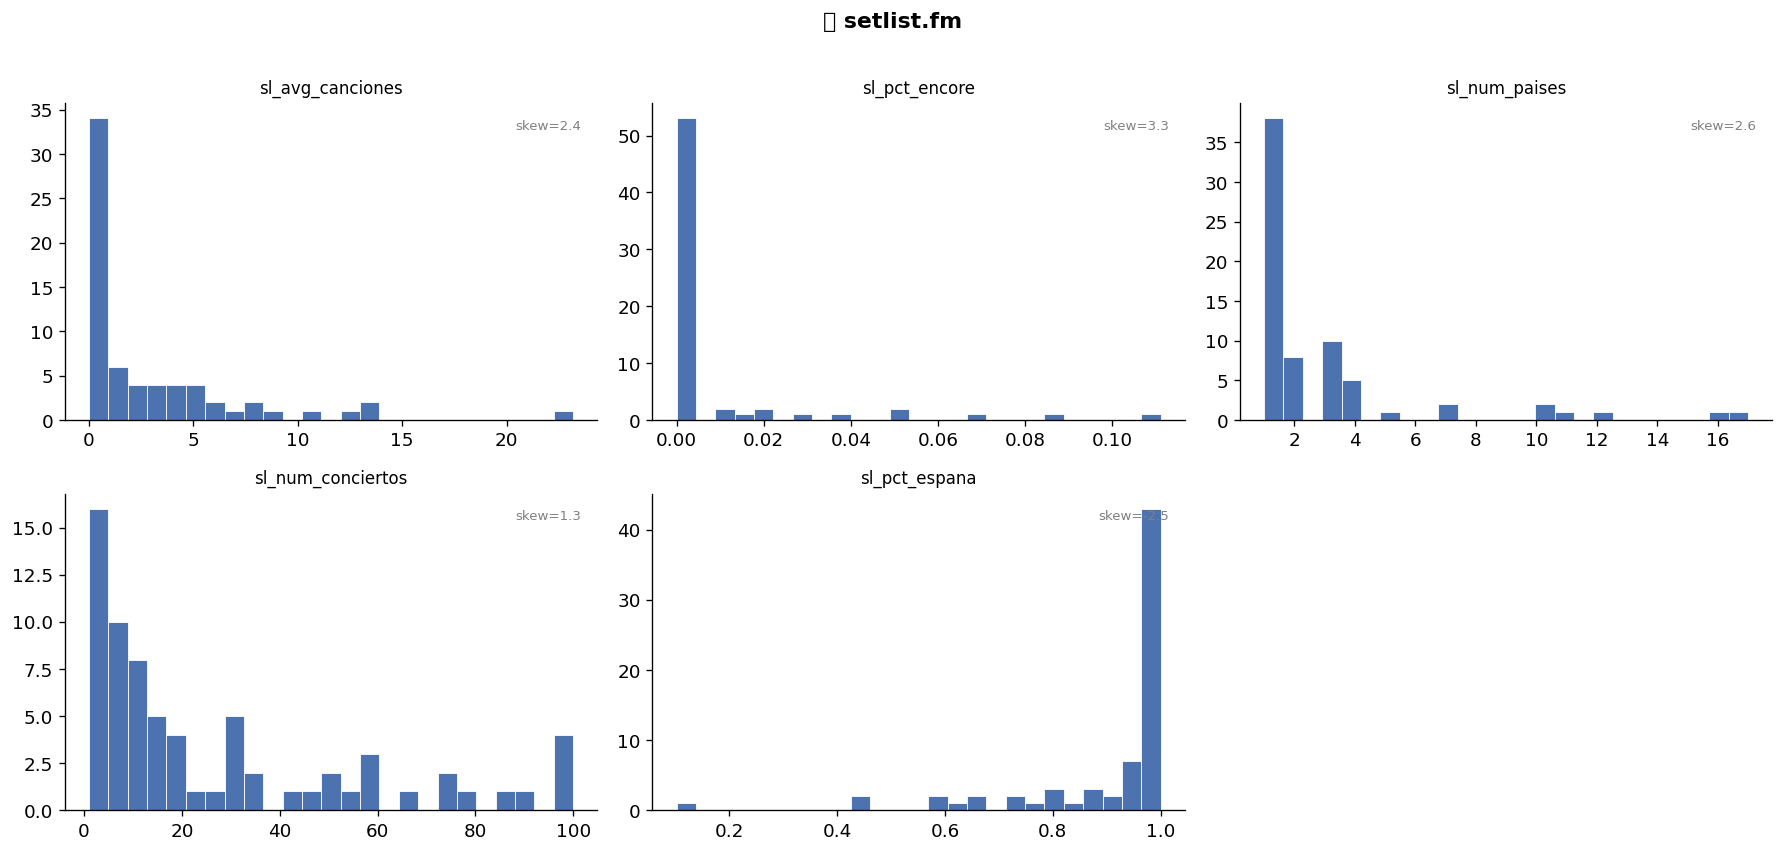

In [5]:
def plot_feature_group(features, title, ncols=3):
    nrows = int(np.ceil(len(features) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
    axes = axes.flatten()
    for i, feat in enumerate(features):
        data = df[feat].dropna()
        axes[i].hist(data, bins=25, color='#4C72B0', edgecolor='white', linewidth=0.5)
        axes[i].set_title(feat, fontsize=10)
        axes[i].set_xlabel('')
        skew = data.skew()
        axes[i].text(0.97, 0.95, f'skew={skew:.1f}', transform=axes[i].transAxes,
                     ha='right', va='top', fontsize=8, color='grey')
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(title, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

plot_feature_group(FEAT_SP,  '📀 Spotify — Discografía + Top Tracks')
plot_feature_group(FEAT_LFM, '🎵 Last.fm')
plot_feature_group(FEAT_YT,  '▶️  YouTube')
plot_feature_group(FEAT_SL,  '🎤 setlist.fm')

## 5. Features vs Target — Boxplots

C:\Users\vicho\AppData\Local\Temp\ipykernel_19272\889180859.py:18: UserWarning: Glyph 128192 (\N{DVD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\vicho\PROYECTOS\prediccion_musical_TFM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128192 (\N{DVD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


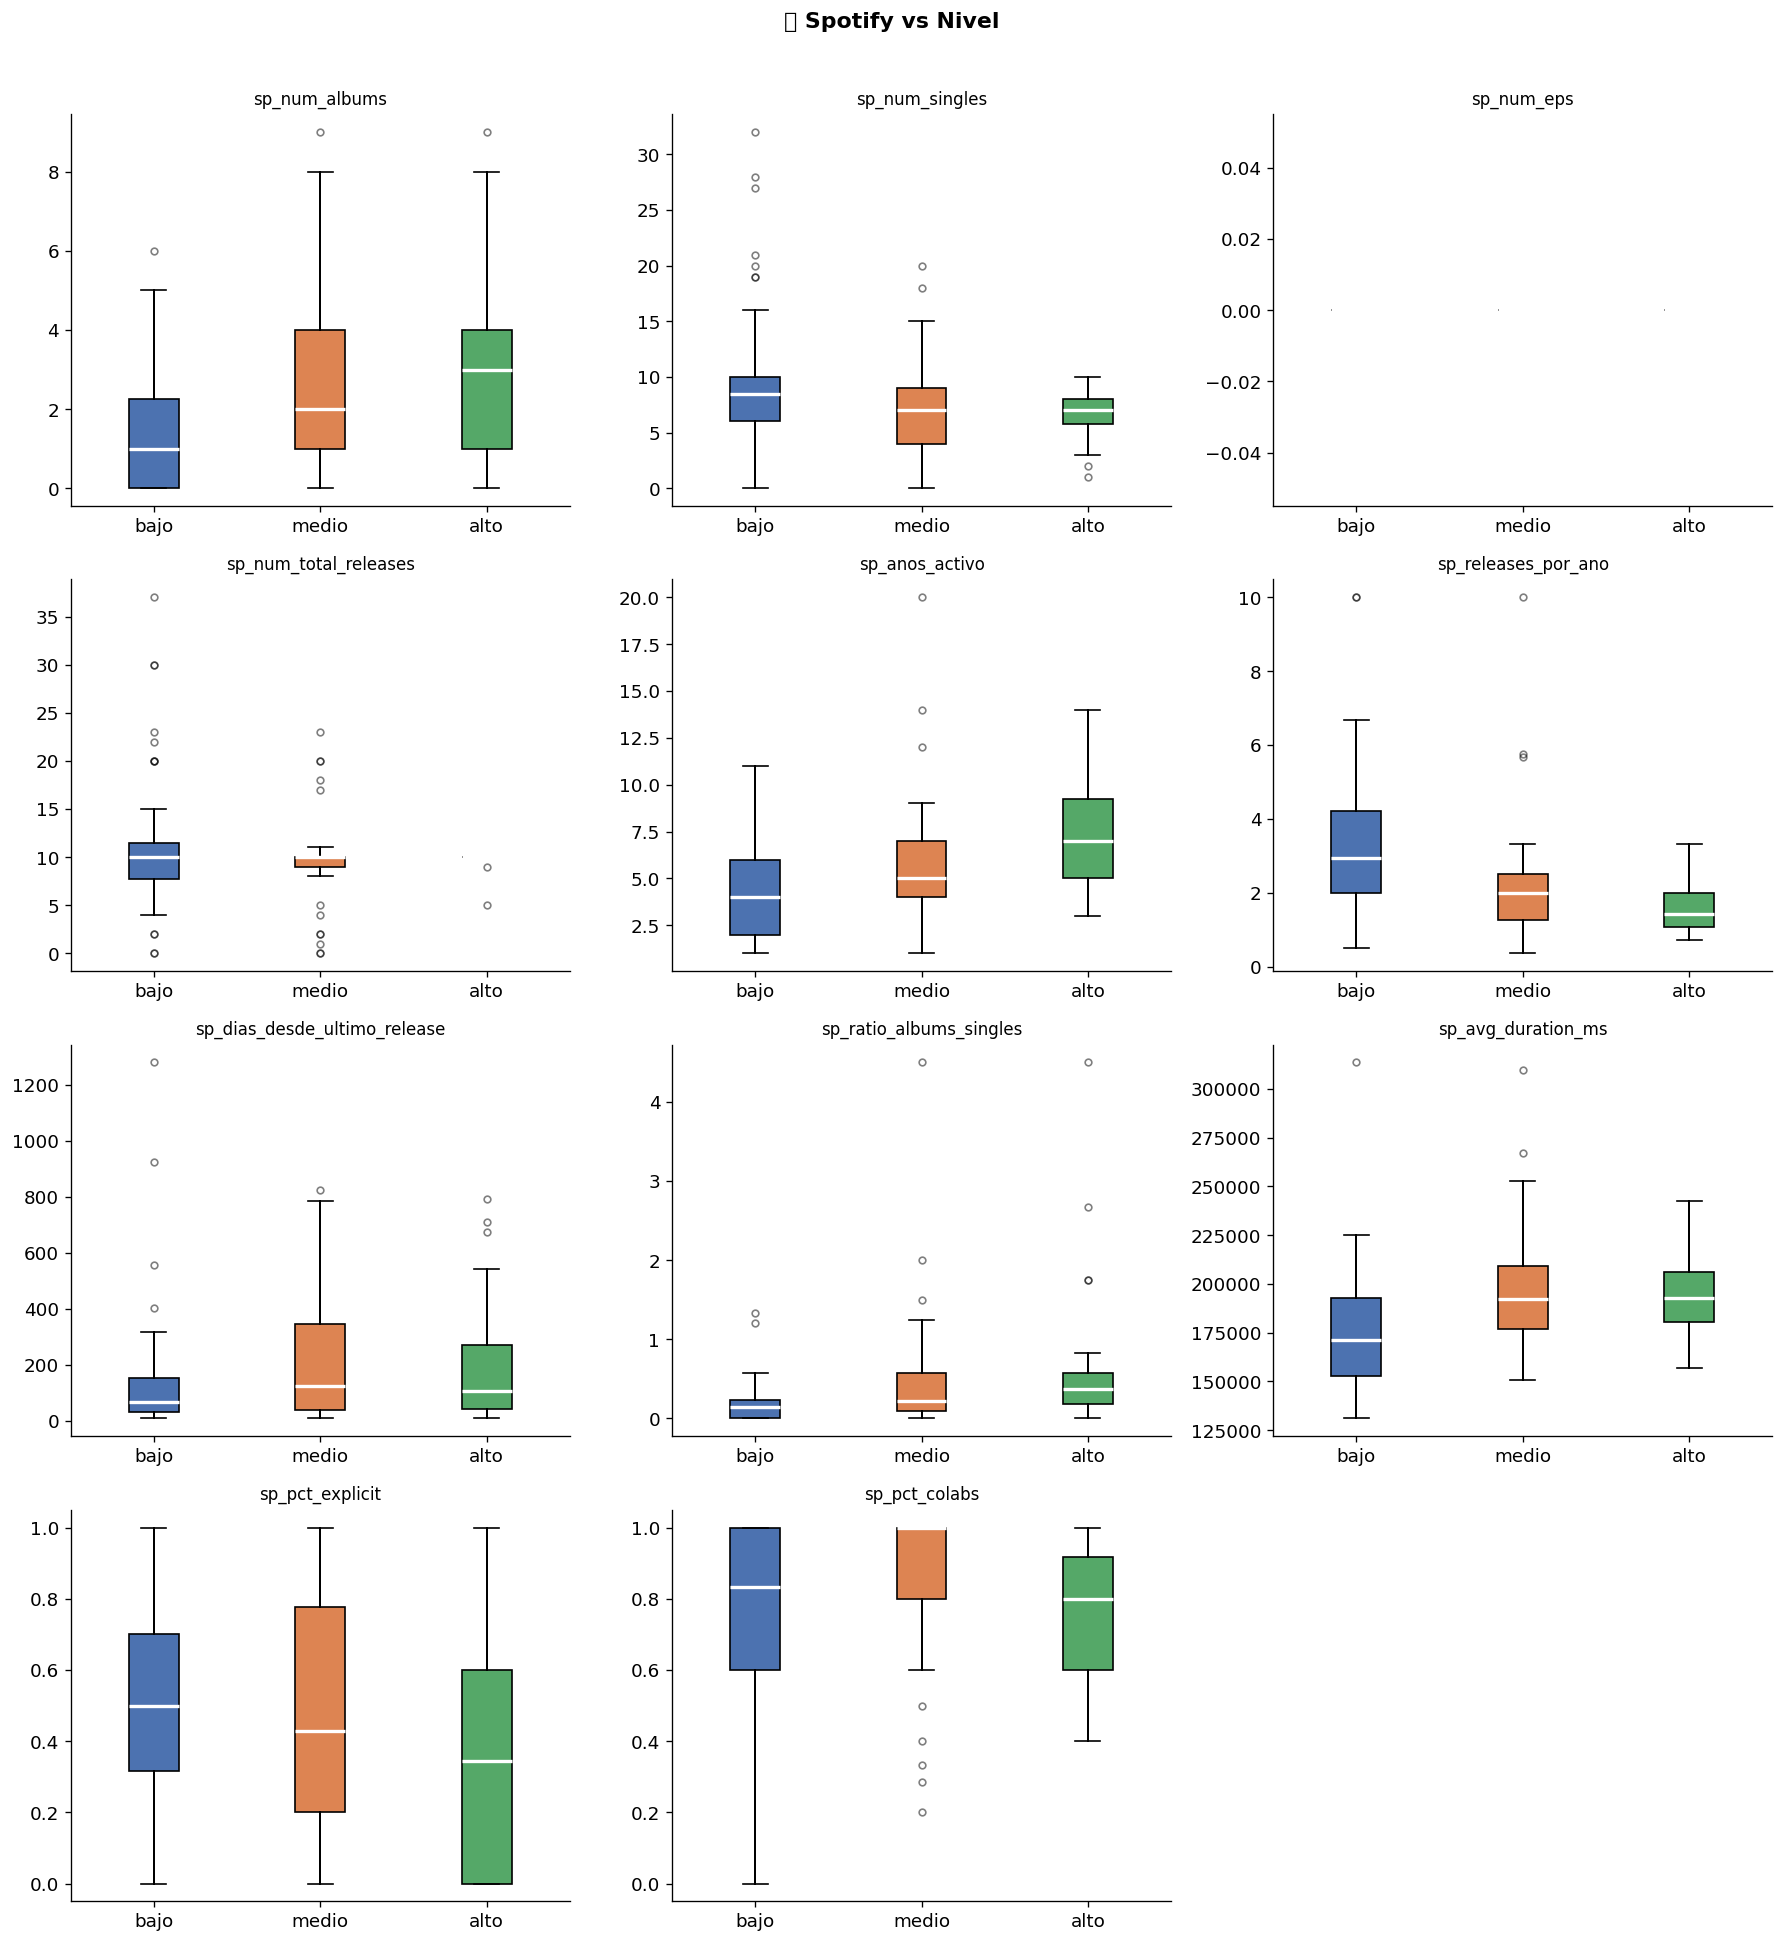

C:\Users\vicho\AppData\Local\Temp\ipykernel_19272\889180859.py:18: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\vicho\PROYECTOS\prediccion_musical_TFM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


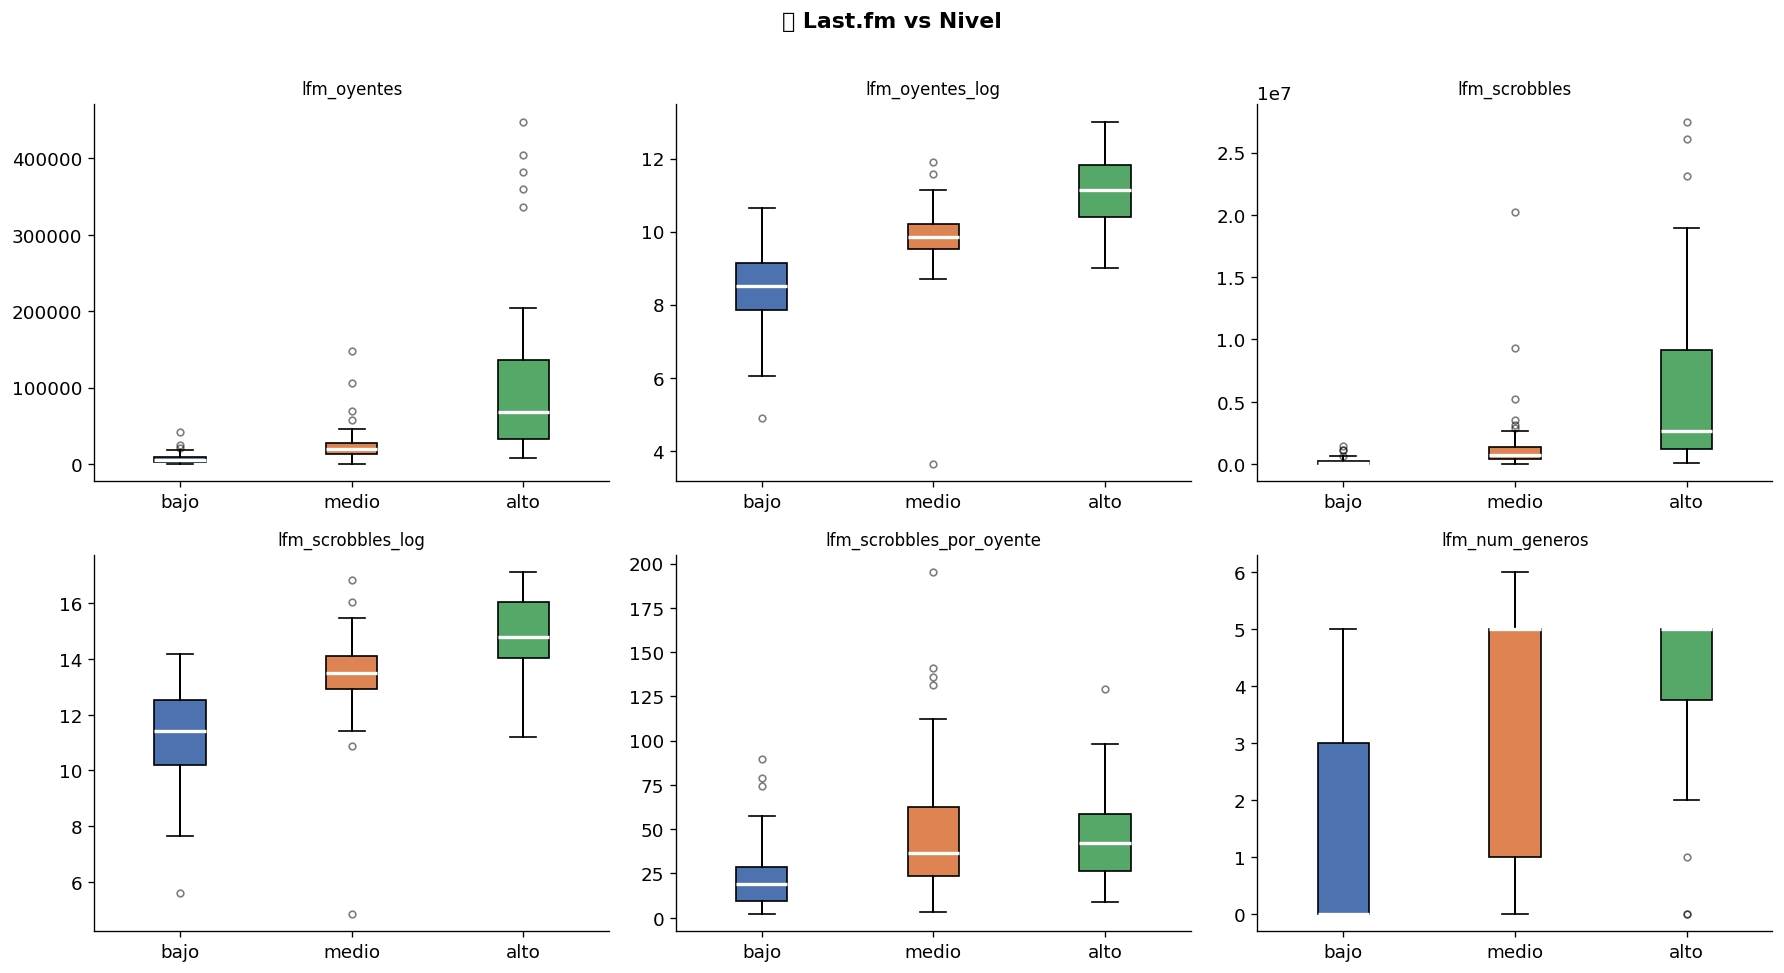

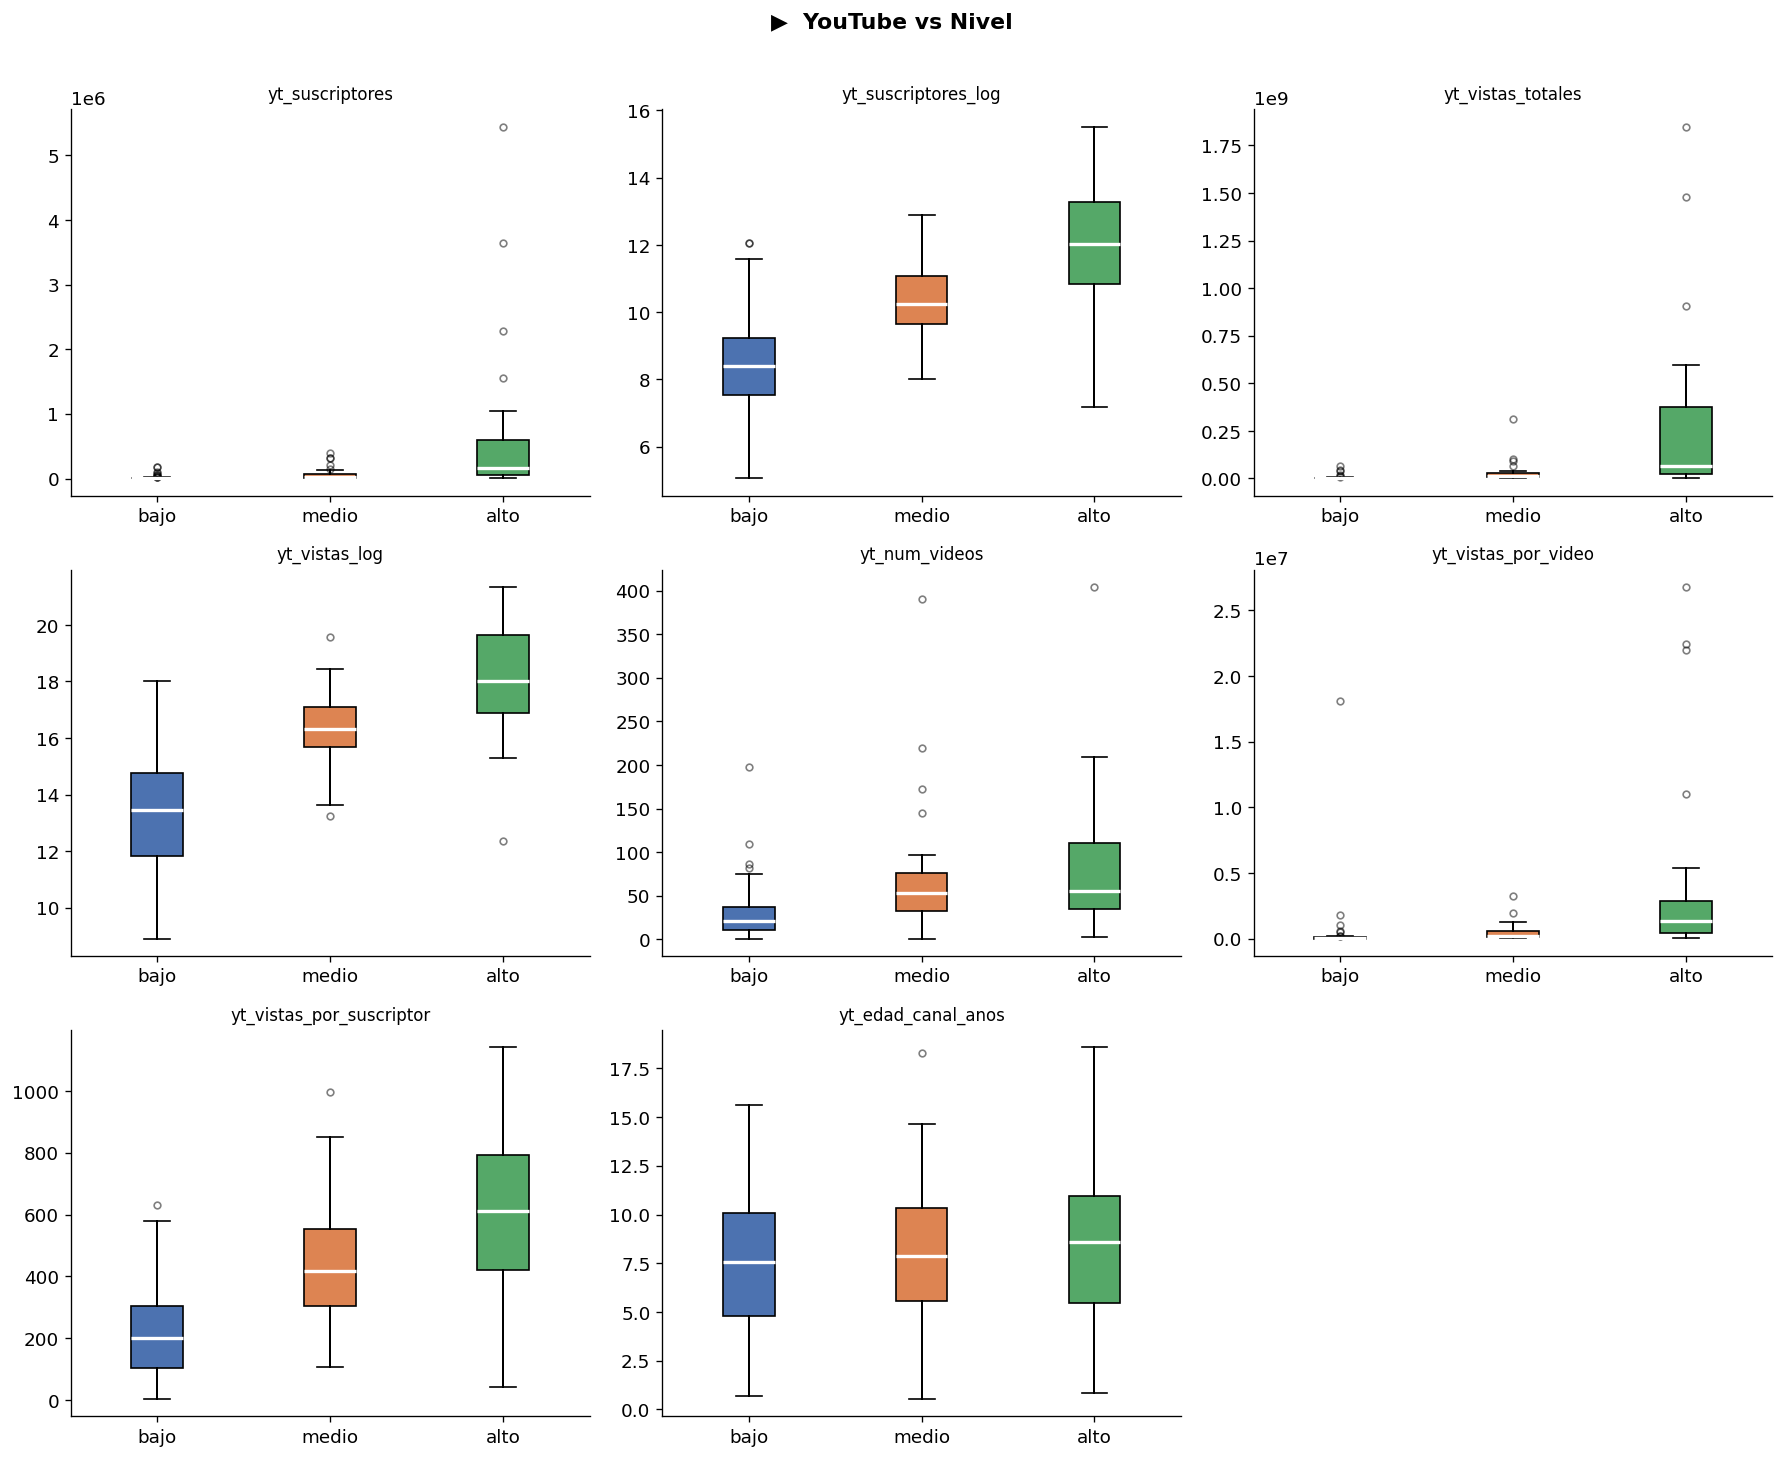

C:\Users\vicho\AppData\Local\Temp\ipykernel_19272\889180859.py:18: UserWarning: Glyph 127908 (\N{MICROPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\vicho\PROYECTOS\prediccion_musical_TFM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127908 (\N{MICROPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


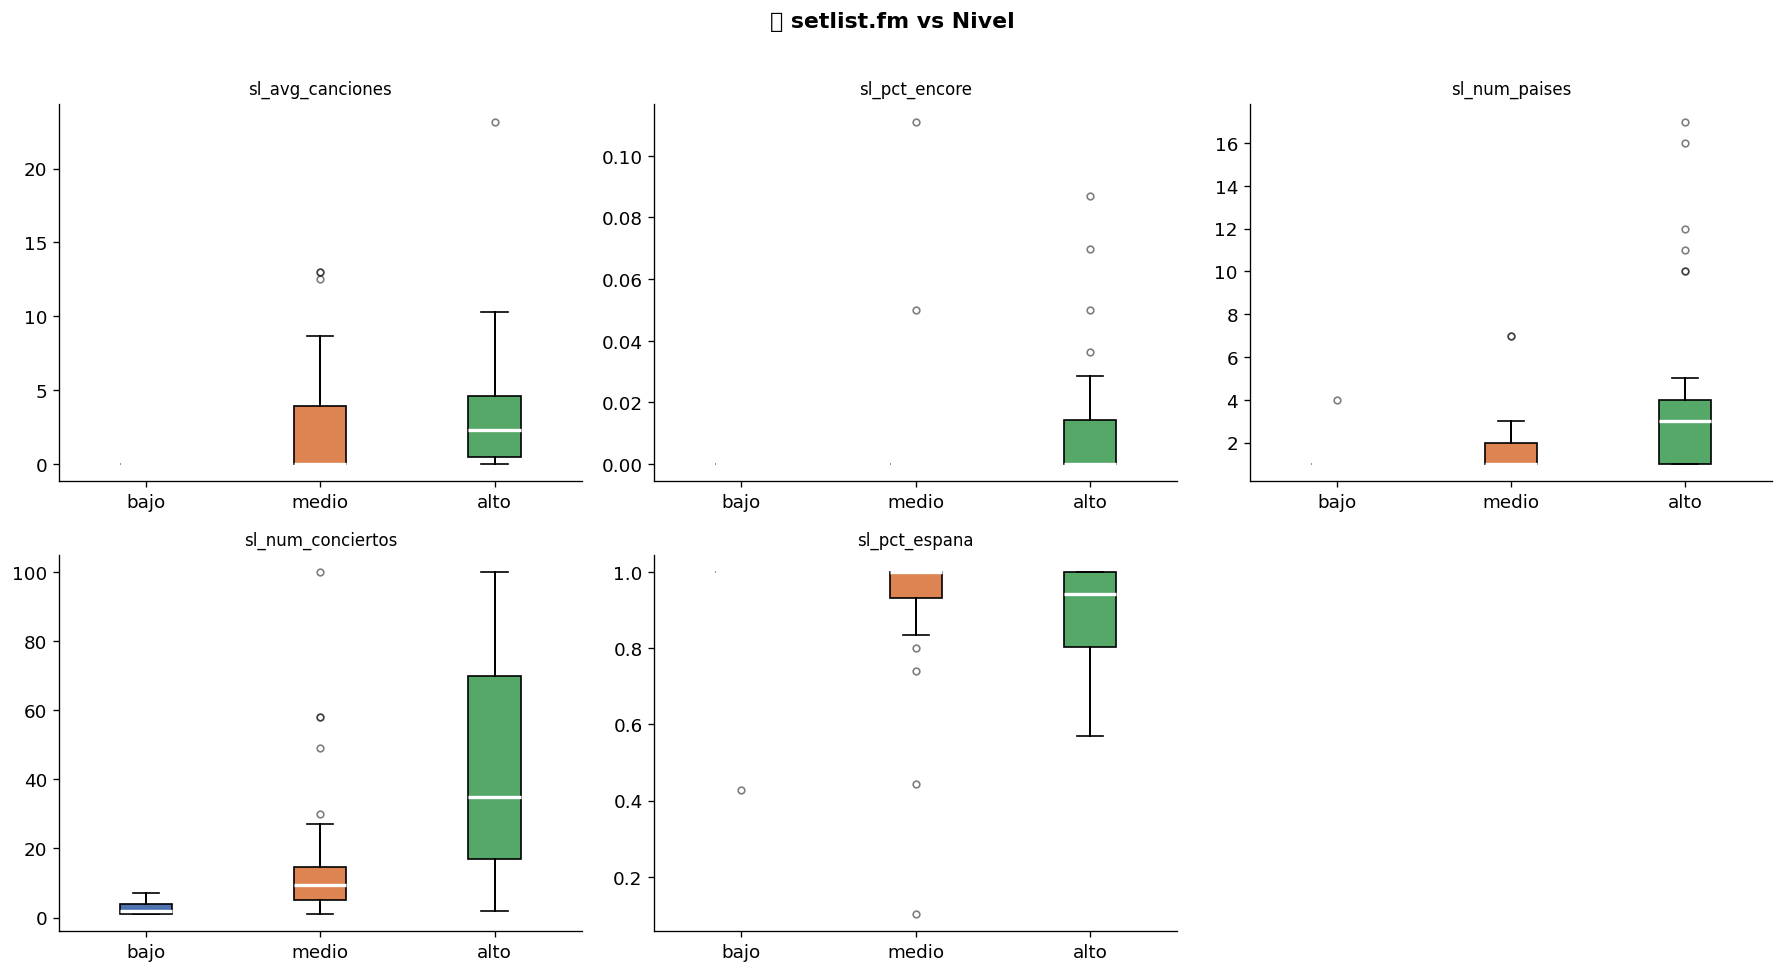

In [6]:
def plot_boxplots_vs_target(features, title, ncols=3):
    nrows = int(np.ceil(len(features) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()
    for i, feat in enumerate(features):
        grupos = [df.loc[df['nivel'] == n, feat].dropna() for n in ORDEN]
        bp = axes[i].boxplot(grupos, patch_artist=True,
                             medianprops={'color': 'white', 'linewidth': 2},
                             whiskerprops={'linewidth': 1.2},
                             flierprops={'marker': 'o', 'markersize': 4, 'alpha': 0.5})
        for patch, nivel in zip(bp['boxes'], ORDEN):
            patch.set_facecolor(PALETTE[nivel])
        axes[i].set_xticklabels(ORDEN)
        axes[i].set_title(feat, fontsize=10)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(title, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

plot_boxplots_vs_target(FEAT_SP,  '📀 Spotify vs Nivel')
plot_boxplots_vs_target(FEAT_LFM, '🎵 Last.fm vs Nivel')
plot_boxplots_vs_target(FEAT_YT,  '▶️  YouTube vs Nivel')
plot_boxplots_vs_target(FEAT_SL,  '🎤 setlist.fm vs Nivel')

## 6. Poder discriminativo — Kruskal-Wallis

c:\Users\vicho\PROYECTOS\prediccion_musical_TFM\.venv\Lib\site-packages\scipy\stats\_stats_py.py:8492: RuntimeWarning: invalid value encountered in scalar divide
  h /= ties


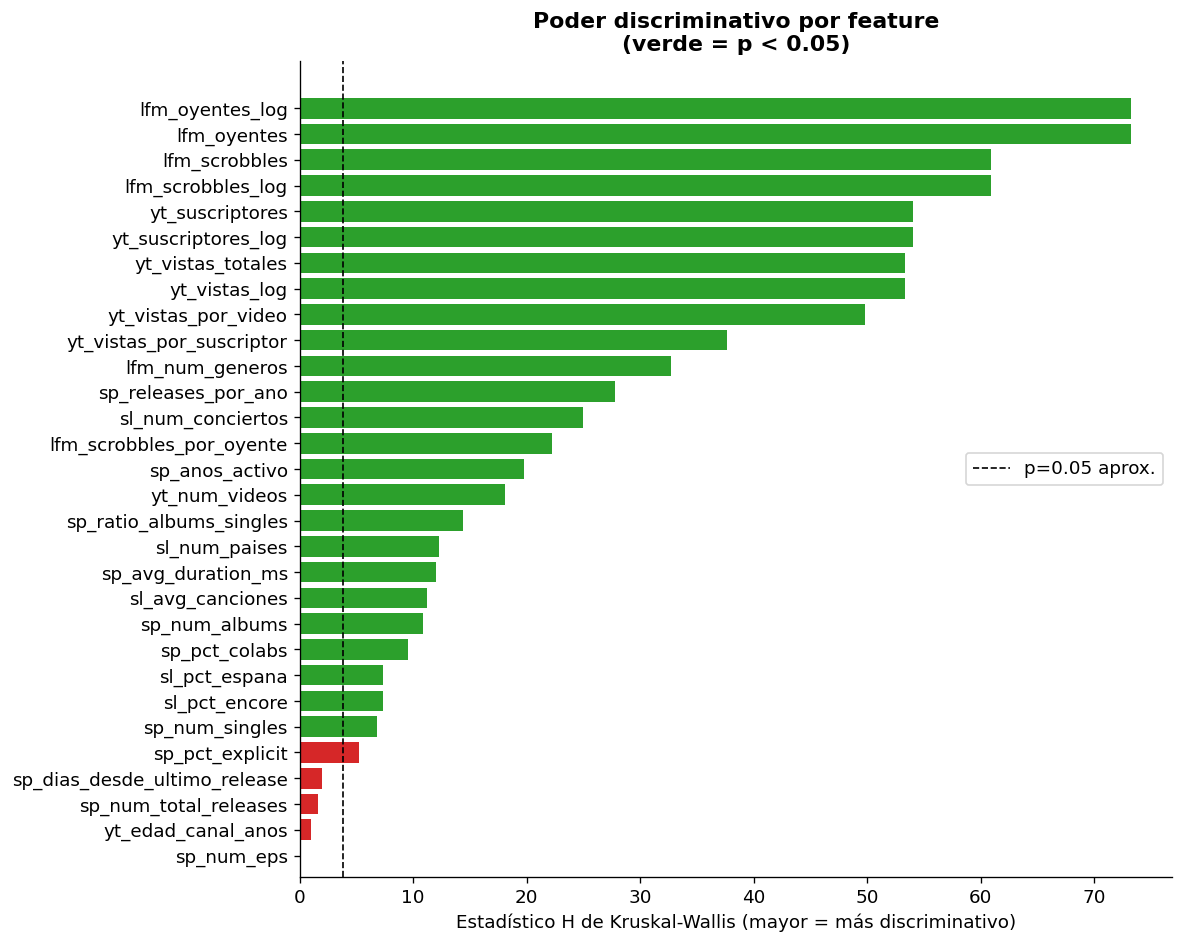


Features significativas (p<0.05): 25 / 30

Top 10 más discriminativas:
                 feature    H_stat      p_value
         lfm_oyentes_log 73.220745 1.259845e-16
             lfm_oyentes 73.220745 1.259845e-16
           lfm_scrobbles 60.943342 5.838770e-14
       lfm_scrobbles_log 60.943342 5.838770e-14
         yt_suscriptores 53.996357 1.882956e-12
     yt_suscriptores_log 53.996357 1.882956e-12
       yt_vistas_totales 53.348445 2.603348e-12
           yt_vistas_log 53.348445 2.603348e-12
     yt_vistas_por_video 49.825516 1.515398e-11
yt_vistas_por_suscriptor 37.627599 6.749486e-09


In [7]:
from scipy import stats

resultados = []
for feat in FEATURES:
    grupos = [df.loc[df['nivel'] == n, feat].dropna().values for n in ORDEN]
    if all(len(g) > 2 for g in grupos):
        stat, p = stats.kruskal(*grupos)
        resultados.append({'feature': feat, 'H_stat': stat, 'p_value': p})

kw = pd.DataFrame(resultados).sort_values('H_stat', ascending=False)
kw['significativa'] = kw['p_value'] < 0.05

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ca02c' if sig else '#d62728' for sig in kw['significativa']]
bars = ax.barh(kw['feature'][::-1], kw['H_stat'][::-1], color=colors[::-1])
ax.axvline(3.84, color='black', linestyle='--', linewidth=1, label='p=0.05 aprox.')
ax.set_xlabel('Estadístico H de Kruskal-Wallis (mayor = más discriminativo)')
ax.set_title('Poder discriminativo por feature\n(verde = p < 0.05)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nFeatures significativas (p<0.05): {kw["significativa"].sum()} / {len(kw)}')
print('\nTop 10 más discriminativas:')
print(kw[['feature', 'H_stat', 'p_value']].head(10).to_string(index=False))

## 7. Matriz de correlaciones

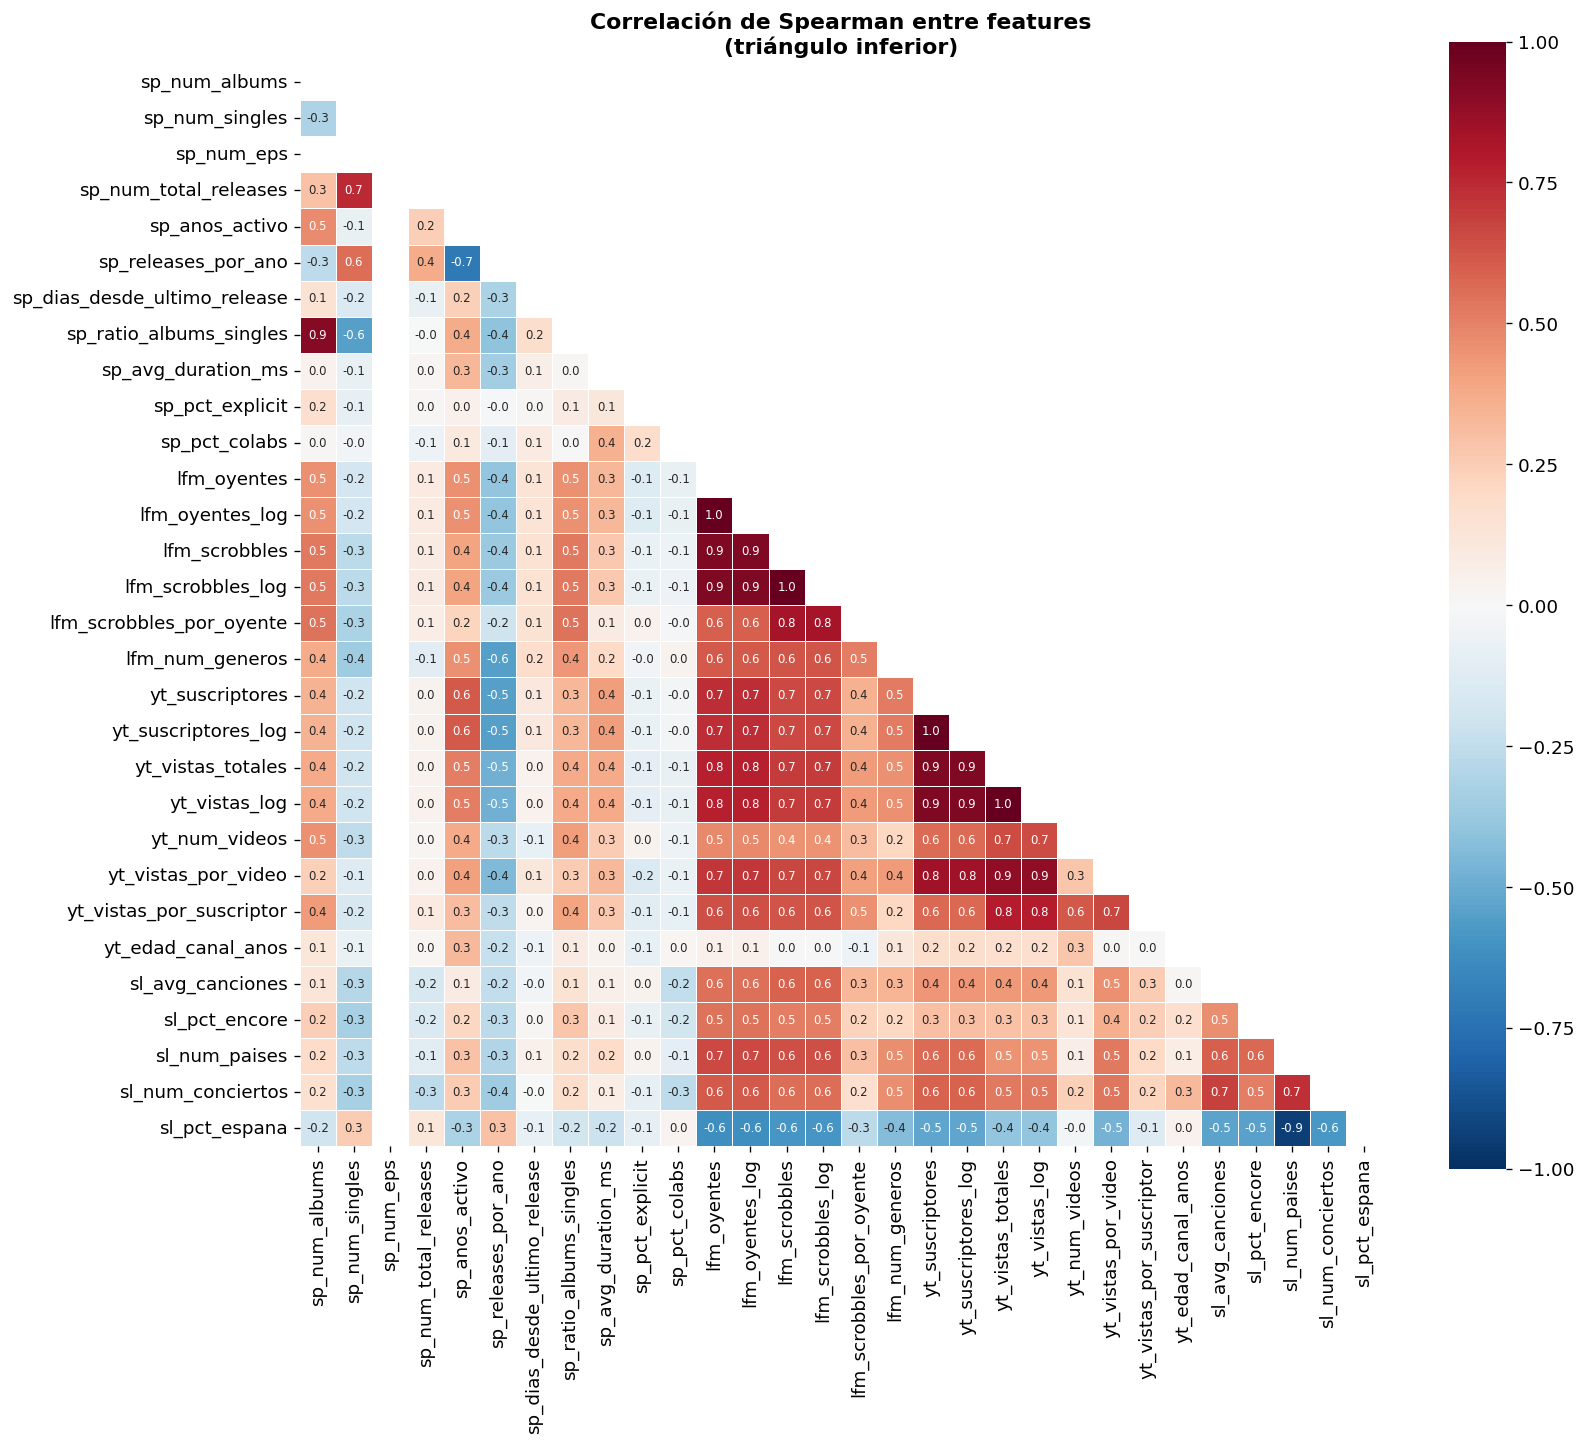

Pares con correlación |r| > 0.85:
                 feat_a              feat_b      corr
        lfm_oyentes_log         lfm_oyentes  1.000000
    yt_suscriptores_log     yt_suscriptores  1.000000
      lfm_scrobbles_log       lfm_scrobbles  1.000000
          yt_vistas_log   yt_vistas_totales  1.000000
      yt_vistas_totales yt_suscriptores_log  0.931554
          yt_vistas_log     yt_suscriptores  0.931554
      yt_vistas_totales     yt_suscriptores  0.931554
          yt_vistas_log yt_suscriptores_log  0.931554
          lfm_scrobbles         lfm_oyentes  0.931498
      lfm_scrobbles_log         lfm_oyentes  0.931498
          lfm_scrobbles     lfm_oyentes_log  0.931498
      lfm_scrobbles_log     lfm_oyentes_log  0.931498
sp_ratio_albums_singles       sp_num_albums  0.912911
    yt_vistas_por_video   yt_vistas_totales  0.886440
    yt_vistas_por_video       yt_vistas_log  0.886440
          sl_pct_espana       sl_num_paises -0.944437


In [8]:
# Solo features con menos del 50% de NaN para que la correlación sea representativa
feat_validas = [f for f in FEATURES if df[f].isna().mean() < 0.5]
corr = df[feat_validas].corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, annot=True, fmt='.1f',
    annot_kws={'size': 7}, linewidths=0.3,
    square=True, ax=ax
)
ax.set_title('Correlación de Spearman entre features\n(triángulo inferior)', fontweight='bold')
plt.tight_layout()
plt.show()

# Pares muy correlacionados (>0.85, excluyendo diagonal y pares raw/log)
corr_pairs = (
    corr.where(mask == False)
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'feat_a', 'level_1': 'feat_b', 0: 'corr'})
)
altas = corr_pairs[corr_pairs['corr'].abs() > 0.85].sort_values('corr', ascending=False)
print('Pares con correlación |r| > 0.85:')
print(altas.to_string(index=False))

## 8. Correlación con el target

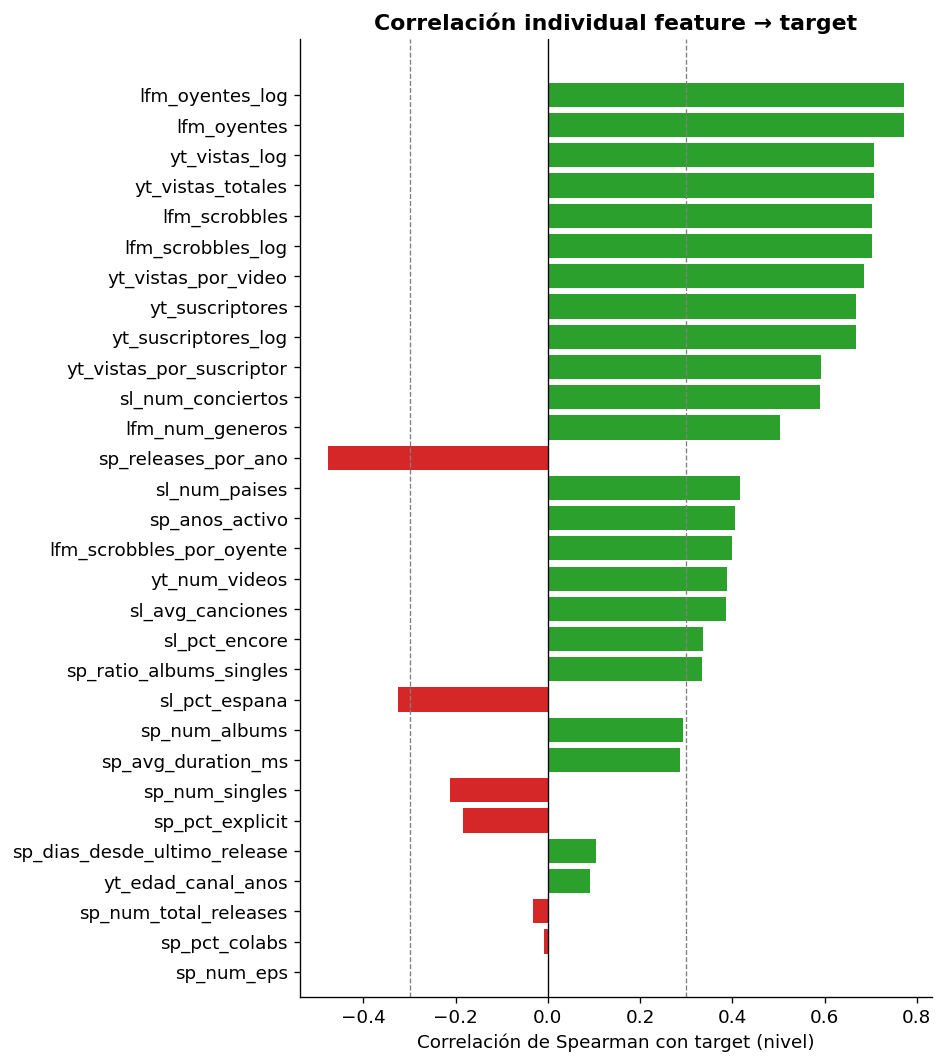

Top 10 features más correlacionadas con el target:
lfm_oyentes_log             0.771391
lfm_oyentes                 0.771391
yt_vistas_log               0.707351
yt_vistas_totales           0.707351
lfm_scrobbles               0.702059
lfm_scrobbles_log           0.702059
yt_vistas_por_video         0.685602
yt_suscriptores             0.668008
yt_suscriptores_log         0.668008
yt_vistas_por_suscriptor    0.591411


In [9]:
corr_target = (
    df[feat_validas + ['target']]
    .corr(method='spearman')['target']
    .drop('target')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 9))
colors = ['#2ca02c' if v > 0 else '#d62728' for v in corr_target]
ax.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.3,  color='grey', linestyle='--', linewidth=0.8)
ax.axvline(-0.3, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Correlación de Spearman con target (nivel)')
ax.set_title('Correlación individual feature → target', fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 10 features más correlacionadas con el target:')
print(corr_target.head(10).to_string())

## 9. Outliers — Z-score

In [10]:
from scipy.stats import zscore

z = df[feat_validas].apply(zscore, nan_policy='omit').abs()
outliers = (z > 3).sum().sort_values(ascending=False)
outliers = outliers[outliers > 0]

print('Features con artistas a >3σ:')
print(outliers.to_string())

# Artistas extremos en cada feature con outliers
print('\nArtistas outlier por feature:')
for feat in outliers.index:
    mask_out = z[feat] > 3
    nombres = df.loc[mask_out, 'nombre_buscado'].tolist()
    vals    = df.loc[mask_out, feat].tolist()
    for n, v in zip(nombres, vals):
        print(f'  {feat}: {n} → {v:.0f}')

Features con artistas a >3σ:
lfm_oyentes                     5
lfm_scrobbles                   5
yt_vistas_por_video             4
sp_releases_por_ano             3
sp_num_singles                  3
sp_ratio_albums_singles         3
sp_pct_colabs                   3
yt_vistas_totales               3
yt_suscriptores                 3
sp_num_total_releases           3
lfm_oyentes_log                 2
sp_dias_desde_ultimo_release    2
sp_num_albums                   2
sp_avg_duration_ms              2
yt_num_videos                   2
sl_num_paises                   2
sl_pct_encore                   2
lfm_scrobbles_por_oyente        2
lfm_scrobbles_log               2
sl_pct_espana                   1
sp_anos_activo                  1
sl_avg_canciones                1

Artistas outlier por feature:
  lfm_oyentes: Rels B → 404442
  lfm_oyentes: Bad Gyal → 448307
  lfm_oyentes: SAIKO → 359900
  lfm_oyentes: Quevedo → 382298
  lfm_oyentes: rusowsky → 336265
  lfm_scrobbles: Rojuu → 20208789

## 10. Resumen por nivel

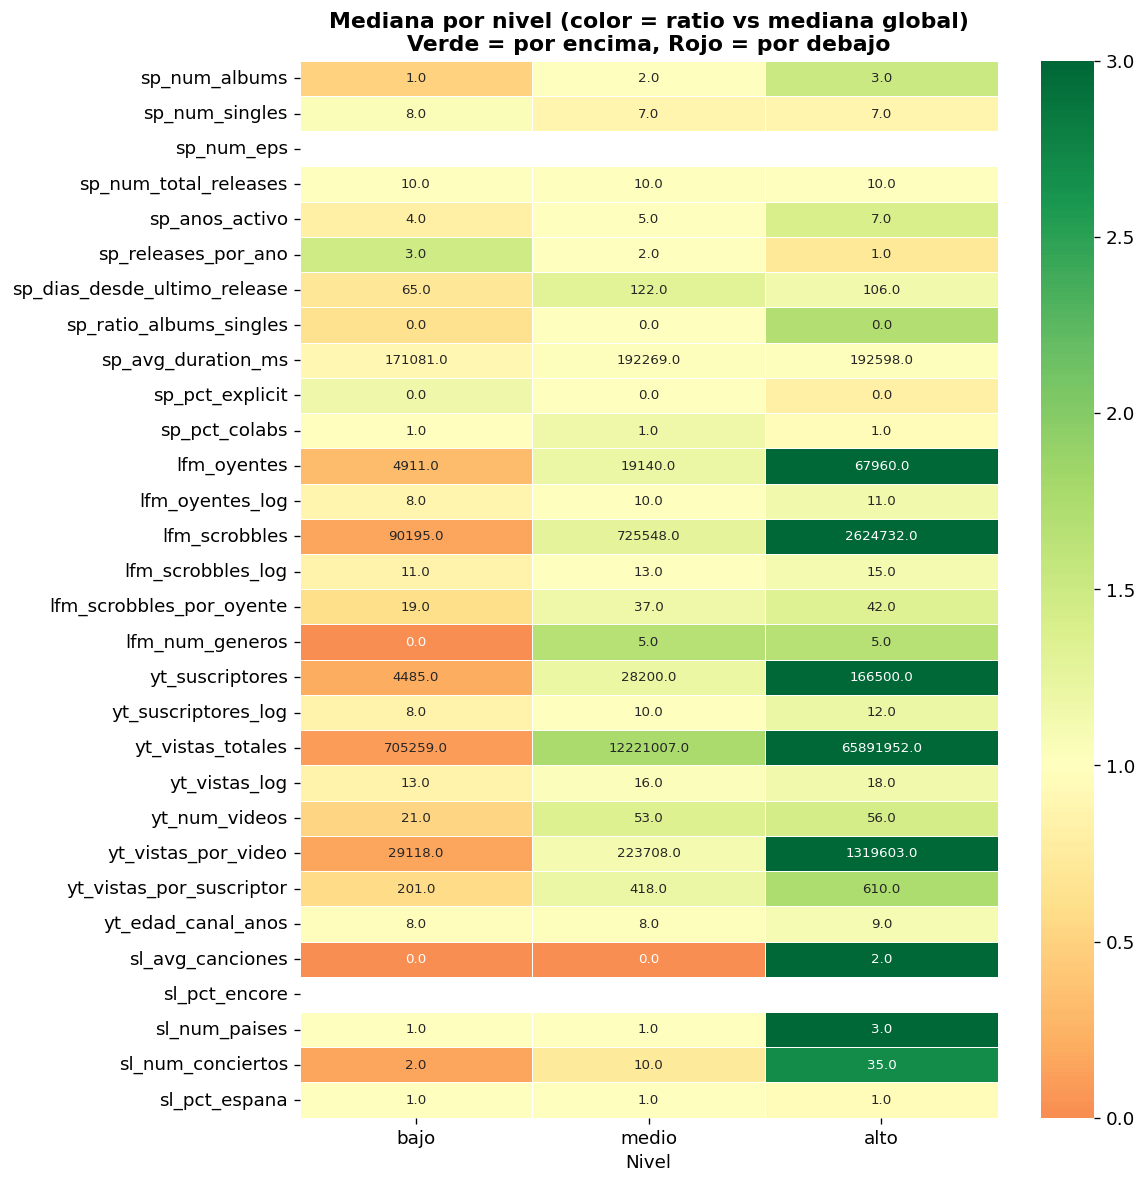

In [11]:
# Mediana de cada feature por nivel
resumen = (
    df.groupby('nivel')[feat_validas]
    .median()
    .reindex(ORDEN)
    .T
)

# Normalizar por la mediana global para ver diferencias relativas
global_median = df[feat_validas].median()
resumen_norm  = resumen.div(global_median.replace(0, np.nan), axis=0)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    resumen_norm,
    cmap='RdYlGn', center=1, vmin=0, vmax=3,
    annot=resumen.round(0).astype(str),
    fmt='', annot_kws={'size': 8},
    linewidths=0.4, ax=ax
)
ax.set_title('Mediana por nivel (color = ratio vs mediana global)\nVerde = por encima, Rojo = por debajo', fontweight='bold')
ax.set_xlabel('Nivel')
plt.tight_layout()
plt.show()

## 11. Conclusiones del EDA

### ✅ Señal general

**25 de 29 features son estadísticamente significativas** (p < 0.05 en Kruskal-Wallis).
La mejor feature individual (`lfm_oyentes_log`) alcanza r ≈ 0.77 con el target.
El dataset tiene señal real y sólida — el modelo tiene base para aprender.

---

### 🏆 Features más discriminativas

| Ranking | Feature | H (KW) | r (Spearman) | Interpretación |
|---|---|---|---|---|
| 1 | `lfm_oyentes_log` | ~73 | +0.77 | Audiencia histórica acumulada — la señal más potente |
| 2 | `lfm_scrobbles` | ~61 | +0.70 | Volumen total de escuchas — fidelidad de la base de fans |
| 3 | `yt_suscriptores` | ~54 | +0.68 | Presencia digital — tamaño de audiencia fiel en YouTube |
| 4 | `yt_vistas_totales` | ~53 | +0.70 | Popularidad acumulada en YouTube |
| 5 | `yt_vistas_por_video` | ~50 | +0.69 | Impacto medio por vídeo — engagement de contenido |
| 6 | `sl_num_conciertos` | ~25 | +0.62 | Actividad en directo — presencia en escena en vivo |

**Last.fm es la fuente más predictiva**, seguida de YouTube.
Ambas capturan el mismo fenómeno desde ángulos distintos: audiencia acumulada y presencia digital.

---

### 🔄 Features con correlación negativa (señales inversas válidas)

- **`sp_releases_por_ano` → r ≈ −0.46**: Los artistas emergentes (nivel bajo) publican más singles
  por año (estrategia streaming-first). Los artistas grandes lanzan menos pero con más impacto.
  Es una señal válida e interpretable — **conservar**.

- **`sl_pct_espana` → r ≈ −0.45**: Los artistas de nivel alto tienen menor porcentaje de conciertos
  en España porque actúan más en el extranjero. La proyección internacional diferencia claramente
  los niveles — **conservar**.

- **`sp_num_singles` → r ≈ −0.20**: Refuerza lo de `sp_releases_por_ano`. Más singles = artista
  más emergente. Señal débil pero coherente.

---

### ⚠️ Redundancias entre features (raw vs log)

`lfm_oyentes` y `lfm_oyentes_log` tienen H y r prácticamente idénticos porque su correlación
entre sí es ≈ 1.0 (una es transformación monótona de la otra). Lo mismo ocurre con:
`lfm_scrobbles`/`lfm_scrobbles_log`, `yt_suscriptores`/`yt_suscriptores_log`, `yt_vistas_totales`/`yt_vistas_log`.

**Para modelos de árbol (Random Forest, XGBoost)**: da igual conservar ambas versiones —
el modelo las evaluará juntas y seleccionará la más útil en cada split. No penaliza la redundancia.

**Para regresión logística**: usar solo las versiones log (distribución más normal, coeficientes
más interpretables y sin problemas de multicolinealidad).

---

### 🗑️ Features de bajo valor (no significativas)

| Feature | H | r | Decisión |
|---|---|---|---|
| `sp_num_eps` | ~0 | ~0 | Eliminar — sin señal ninguna |
| `sp_num_total_releases` | ~2 | ~−0.04 | Eliminar — redundante con albums + singles |
| `sp_dias_desde_ultimo_release` | ~2 | ~+0.10 | Eliminar — no discrimina niveles |
| `yt_edad_canal_anos` | ~1 | ~+0.10 | Eliminar — no discrimina niveles |
| `sp_pct_colabs` | ~10 | ~−0.02 | Mantener en árbol, eliminar en regresión |

> Estas features se mantienen en `artist_features.csv`.
> Se excluirán en el paso de preprocesado antes del entrenamiento.

---

### 🔺 Outliers destacados

Los outliers son **artistas reales de nivel alto** con métricas extremas, no errores de datos:
- `yt_vistas_totales`: Quevedo (~1.8B), Bad Gyal (~1.5B), Natos y Waor (~908M)
- `lfm_scrobbles`: Rels B (~27M), Bad Gyal (~26M), Quevedo (~23M)
- `yt_suscriptores`: Rels B (5.4M), Morad (3.65M), Quevedo (2.3M)
- `sp_releases_por_ano` extremos: AmoryOdio, ladiferencia2006 (10/año) — artistas muy nuevos

**No eliminar** estos artistas — son exactamente los ejemplos de 'alto' que el modelo necesita aprender.
Usar **RobustScaler** en regresión logística para que no distorsionen el escalado.

---

### 📋 Decisiones para el preprocesado (próximo paso)

**Imputación de NaN:**
- `sl_num_conciertos`, `sl_num_paises` → **0** (sin shows registrados = 0 shows)
- `sl_avg_canciones`, `sl_pct_encore`, `sl_pct_espana` → **mediana** (ratios sin denominador)
- `yt_vistas_totales`, `yt_num_videos` y derivados → **mediana por nivel**
- Resto (< 4% NaN) → **0**

**Escalado:**
- Random Forest / XGBoost: **no necesitan escalado**
- Regresión logística: **RobustScaler** (resiste outliers extremos)

**Features a excluir en el entrenamiento:**
`sp_num_eps`, `sp_num_total_releases`, `sp_dias_desde_ultimo_release`, `yt_edad_canal_anos`